# Ticket Analytics — Module 1: EDA
## AI-Driven Intelligent IT Operations Platform | Innodatatics Capstone — ISB AMPBA 2025W

This notebook is **Module 1 of 4** in the ticket analytics stream.

### What this notebook does
- Loads and consolidates three years of IT operations data (2023–2025)
- Validates schema against the registry in `schema_utils.py` and logs any drift
- Builds the merged analytical base (`ticket_base.pkl`)
- Runs EDA across all key dimensions
- Prepares `reco_base.pkl` — filtered dataset for the recommendation engine in NB2

### Outputs saved to Google Drive (`ticket_pkl_outputs/`)
| File | Used by |
|---|---|
| `ticket_base.pkl` | NB2, NB3, NB4 |
| `reco_base.pkl` | NB2, NB3 |
| `engineer_perf.pkl` | NB3 |
| `schema_diffs.pkl` | NB2 |
| `resolution_driver_tables.pkl` | NB4 |
| `volume_driver_tables.pkl` | NB4 |

### Run order
**Run this notebook first.** All other modules depend on its outputs.


In [1]:
# ============================================================
# COLAB + GOOGLE DRIVE SETUP — run this cell first every session
# ============================================================
# This cell mounts Google Drive and sets all path variables so every
# notebook reads data from Drive and writes outputs back to Drive.
# No manual uploads or downloads are needed between sessions.
#
# One-time folder structure in your Drive:
#   My Drive/
#   └── Innodatatics_Capstone/
#       ├── data/                     ← all Excel files go here
#       ├── NLP_Ticket_Analytics/     ← all 4 notebooks + schema_utils.py
#       ├── ticket_pkl_outputs/       ← auto-created
#       ├── ticket_eda_plots/         ← auto-created
#       ├── ticket_dashboard_outputs/ ← auto-created
#       └── model_outputs/            ← auto-created
# ============================================================

from google.colab import drive
import os
import sys

drive.mount("/content/drive", force_remount=False)

# Change BASE if your Drive path is different
BASE = "/content/drive/MyDrive/Innodatatics_Capstone"
NLP  = f"{BASE}/NLP_Ticket_Analytics"
DATA = f"{BASE}/data"

os.chdir(NLP)
sys.path.insert(0, NLP)

from pathlib import Path

PKL_DIR  = Path(f"{BASE}/ticket_pkl_outputs");      PKL_DIR.mkdir(exist_ok=True)
PLOT_DIR = Path(f"{BASE}/ticket_eda_plots");         PLOT_DIR.mkdir(exist_ok=True)
DASH_DIR = Path(f"{BASE}/ticket_dashboard_outputs"); DASH_DIR.mkdir(exist_ok=True)
JSON_DIR = Path(f"{BASE}/model_outputs");            JSON_DIR.mkdir(exist_ok=True)

FILES = {
    2023: Path(f"{DATA}/IT_Ops_Intern_Ready_2023.xlsx"),
    2024: Path(f"{DATA}/IT_Ops_Intern_Ready_2024.xlsx"),
    2025: Path(f"{DATA}/IT_Ops_Intern_Ready_2025.xlsx"),
}
SYNTH_FILE      = Path(f"{DATA}/ticket_assignment_synthetic.xlsx")
HIST_SYNTH_FILE = Path(f"{DATA}/ticket_assignment_history_synthetic.xlsx")
ENG_FILE_2025   = Path(f"{DATA}/IT_Ops_Intern_Ready_2025.xlsx")

print("✅  Drive mounted")
print(f"   Working dir : {os.getcwd()}")
print(f"   PKL dir     : {PKL_DIR}")
print(f"   Data files  : {[f.name for f in FILES.values()]}")
missing = [str(p) for p in FILES.values() if not p.exists()]
if missing:
    print(f"\n⚠️  Missing: {missing}")
    print("   Upload these to your Drive data/ folder and re-run.")
else:
    print("   All data files found ✅")


Mounted at /content/drive
✅  Drive mounted
   Working dir : /content/drive/MyDrive/Innodatatics_Capstone/NLP_Ticket_Analytics
   PKL dir     : /content/drive/MyDrive/Innodatatics_Capstone/ticket_pkl_outputs
   Data files  : ['IT_Ops_Intern_Ready_2023.xlsx', 'IT_Ops_Intern_Ready_2024.xlsx', 'IT_Ops_Intern_Ready_2025.xlsx']
   All data files found ✅


# 1. Imports & Settings

## Objective
Load all required libraries and define helper functions used throughout this notebook.

## Libraries used
- `pandas`, `numpy` — data manipulation and numerics
- `matplotlib`, `seaborn` — visualisation
- `openpyxl` — Excel reading
- `schema_utils` — project schema registry, drift detection, and dynamic feature pools

## Helper functions defined here
- `save_pkl()` — persist any object to Drive's pkl directory
- `save_plot()` — save current figure to Drive's plot directory
- `add_data_labels()` — annotate bar/line charts with values (presentation-ready)
- `labeled_bar()` — one-call bar chart with data labels


In [3]:
# =========================
# 1A. Install (uncomment on first run if packages are not already included)
# =========================
# %pip install pandas numpy matplotlib seaborn openpyxl scikit-learn pathlib
#
# Note: schema_utils.py must be present in NLP_Ticket_Analytics/ on Drive.
# It was uploaded alongside these notebooks.

# =========================
# 1B. Core imports
# =========================
import warnings
warnings.filterwarnings("ignore")

import os
import pickle
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from pathlib import Path
from IPython.display import display

# =========================
# 1C. Schema utilities
# =========================
# schema_utils.py is the single source of truth for expected column schemas.
# It detects added, removed, renamed and type-changed columns at load time.
import importlib
try:
    import schema_utils as su
    importlib.reload(su)
    from schema_utils import (
        validate_and_diff,
        dynamic_feature_pools,
        print_schema_summary,
        SchemaChangeError
    )
    SCHEMA_UTILS_AVAILABLE = True
    print("✅ schema_utils loaded")
except ImportError:
    SCHEMA_UTILS_AVAILABLE = False
    print("⚠️ schema_utils.py not found. Copy it to NLP_Ticket_Analytics/ and re-run.")

# =========================
# 1D. Global settings
# =========================
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

RANDOM_STATE = 42

# Schema drift log — appended every run to track schema changes across data deliveries
SCHEMA_LOG = PKL_DIR / "schema_drift_log.json"

# =========================
# 1E. Helper functions
# =========================
def save_pkl(obj, name):
    """Pickle an object to PKL_DIR on Drive and confirm."""
    path = PKL_DIR / name
    with open(path, "wb") as f:
        pickle.dump(obj, f)
    print(f"  ✅  Saved → {path}")

def save_plot(name):
    """Tight-layout, save to PLOT_DIR on Drive, then show."""
    plt.tight_layout()
    plt.savefig(PLOT_DIR / name, dpi=150, bbox_inches="tight")
    print(f"  ✅  Plot saved → {PLOT_DIR / name}")
    plt.show()

def add_data_labels(ax, x_vals, y_vals, percent=False):
    """Add value labels above each bar or data point for presentation-ready charts."""
    for x, y in zip(x_vals, y_vals):
        if pd.isna(y):
            continue
        label = f"{y:.1%}" if percent else f"{int(round(float(y))):,}"
        ax.annotate(label, (x, y), textcoords="offset points",
                    xytext=(0, 6), ha="center", fontsize=8)

def labeled_bar(series, title, xlabel, ylabel, rotate=0, percent=False, save=None):
    """Render a bar chart with value labels on every bar."""
    series = series.dropna()
    fig, ax = plt.subplots(figsize=(9, 4.8))
    x_vals = list(range(len(series)))
    ax.bar(x_vals, series.values, color="#4472C4")
    ax.set_xticks(x_vals)
    ax.set_xticklabels(series.index.astype(str),
                       rotation=rotate, ha="right" if rotate else "center")
    add_data_labels(ax, x_vals, series.values, percent=percent)
    if percent:
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if save:
        save_plot(save)
    else:
        plt.tight_layout()
        plt.show()

print("✅  All imports, settings and helpers ready")


✅ schema_utils loaded
✅  All imports, settings and helpers ready


# 2. Data Loading & Consolidation

## Objective
Load all three yearly Excel files, standardise column names, tag each row with its source year,
and combine into unified tables across all 9 sheets.

## Why this matters
- Ticket IDs reset each year — `year_ticket_id = "2023_T000001"` is the stable unique key.
- Loading and joining all master tables early gives the merged base the full context
  needed for feature engineering and model training in NB2.
- Schema consistency is validated immediately after loading so drift is caught before
  any downstream work begins.

## Unique key design
`year_ticket_id = str(year) + "_" + ticket_id`


In [4]:
# =========================
# 2A. Load all sheets across 3 years
# =========================
REQUIRED_SHEETS = [
    "SERVICE_TICKETS",
    "ASSET_MASTER",
    "ENGINEER_MASTER",
    "CLIENT_MASTER",
    "HARDWARE_TELEMETRY",
    "SLA_RULES"
]

def clean_columns(df):
    """Lowercase and strip all column names for consistent key access."""
    df = df.copy()
    df.columns = [str(c).strip().lower() for c in df.columns]
    return df

def load_yearly_sheets(files_dict, sheets):
    """
    Load every sheet from every yearly file, tag rows with source year,
    concatenate across years, and return a schema map for drift detection.
    """
    data = {s.lower(): [] for s in sheets}
    schema_map = {}

    for year, file_path in files_dict.items():
        assert file_path.exists(), f"Missing file: {file_path}"
        print(f"  Reading {file_path.name} ...")
        xls = pd.ExcelFile(file_path)

        for sheet in sheets:
            if sheet not in xls.sheet_names:
                print(f"    ⚠️  {sheet} not found in {file_path.name}")
                continue
            df = pd.read_excel(file_path, sheet_name=sheet)
            df = clean_columns(df)
            df["year"] = year
            data[sheet.lower()].append(df)
            schema_map.setdefault(sheet.lower(), {})[year] = list(df.columns)
            print(f"    {sheet:<28} → {len(df):>6,} rows")

    combined = {
        name: pd.concat(parts, ignore_index=True, sort=False)
        for name, parts in data.items()
        if parts
    }
    return combined, schema_map

print("Loading 2023, 2024, 2025 ...")
tables, schema_map = load_yearly_sheets(FILES, REQUIRED_SHEETS)

tickets   = tables["service_tickets"].copy()
assets    = tables["asset_master"].copy()
engineers = tables["engineer_master"].copy()
clients   = tables["client_master"].copy()
telemetry = tables["hardware_telemetry"].copy()
sla_rules = tables["sla_rules"].copy()

print("\nCombined table shapes:")
for name, df in dict(tickets=tickets, assets=assets, engineers=engineers,
                     clients=clients, telemetry=telemetry, sla_rules=sla_rules).items():
    print(f"  {name:12s} → {df.shape[0]:>7,} rows × {df.shape[1]} cols")


Loading 2023, 2024, 2025 ...
  Reading IT_Ops_Intern_Ready_2023.xlsx ...
    SERVICE_TICKETS              →  6,968 rows
    ASSET_MASTER                 →    151 rows
    ENGINEER_MASTER              →     20 rows
    CLIENT_MASTER                →     25 rows
    HARDWARE_TELEMETRY           → 15,057 rows
    SLA_RULES                    →     12 rows
  Reading IT_Ops_Intern_Ready_2024.xlsx ...
    SERVICE_TICKETS              →  8,044 rows
    ASSET_MASTER                 →    151 rows
    ENGINEER_MASTER              →     20 rows
    CLIENT_MASTER                →     25 rows
    HARDWARE_TELEMETRY           → 15,057 rows
    SLA_RULES                    →     12 rows
  Reading IT_Ops_Intern_Ready_2025.xlsx ...
    SERVICE_TICKETS              →  7,479 rows
    ASSET_MASTER                 →    151 rows
    ENGINEER_MASTER              →     20 rows
    CLIENT_MASTER                →     25 rows
    HARDWARE_TELEMETRY           → 15,057 rows
    SLA_RULES                    →     1

In [5]:
# =========================
# 2B. Schema validation — run immediately after load
# =========================
# Compares each loaded table to the registry in schema_utils.py.
# Results are printed and appended to schema_drift_log.json on Drive.
#
# Actions taken:
#   NEW columns      → logged; auto-classified as candidate features in NB2
#   REMOVED optional → warning logged; pipeline continues
#   REMOVED required → SchemaChangeError raised; pipeline stops
#   TYPE CHANGES    → logged; investigate before trusting model outputs

schema_diffs = {}

if SCHEMA_UTILS_AVAILABLE:
    for tname, df_check in [
        ("service_tickets",   tickets),
        ("asset_master",      assets),
        ("engineer_master",   engineers),
        ("client_master",     clients),
        ("hardware_telemetry",telemetry),
        ("sla_rules",         sla_rules),
    ]:
        try:
            schema_diffs[tname] = validate_and_diff(
                df_check, tname,
                log_path=SCHEMA_LOG,
                raise_on_required=True
            )
        except SchemaChangeError as e:
            print(f"\n❌  PIPELINE STOPPED — {e}")
            raise

    print_schema_summary(schema_diffs)
    save_pkl(schema_diffs, "schema_diffs.pkl")
else:
    print("ℹ️  Schema validation skipped — schema_utils not available")
    schema_diffs = {}



  SCHEMA DIFF — service_tickets  at 2026-05-20 03:07:48
  ➕ NEW columns (1) — will be auto-classified as candidate features:
     + year                                     [num]


  SCHEMA DIFF — asset_master  at 2026-05-20 03:07:48
  ➕ NEW columns (1) — will be auto-classified as candidate features:
     + year                                     [num]


  SCHEMA DIFF — engineer_master  at 2026-05-20 03:07:49
  ➕ NEW columns (1) — will be auto-classified as candidate features:
     + year                                     [num]


  SCHEMA DIFF — client_master  at 2026-05-20 03:07:49
  ➕ NEW columns (1) — will be auto-classified as candidate features:
     + year                                     [num]


  SCHEMA DIFF — hardware_telemetry  at 2026-05-20 03:07:49
  ➕ NEW columns (2) — will be auto-classified as candidate features:
     + client_id                                [cat]
     + year                                     [num]


  SCHEMA DIFF — sla_rules  at 2026-05-20 0

In [6]:
# =========================
# 2C. Composite unique key and row count validation
# =========================
# Ticket IDs reset each year, so year_ticket_id is the stable unique key.
# We also validate that row counts match the known delivery counts.

tickets["year_ticket_id"] = (
    tickets["year"].astype(str) + "_" + tickets["ticket_id"].astype(str)
)

ticket_counts = (
    tickets.groupby("year")
    .agg(
        rows                = ("ticket_id",       "size"),
        unique_ticket_ids   = ("ticket_id",       "nunique"),
        unique_composite    = ("year_ticket_id",  "nunique")
    )
    .reset_index()
)
ticket_counts["within_year_duplicates"] = (
    ticket_counts["rows"] - ticket_counts["unique_ticket_ids"]
)
display(ticket_counts)

dups = ticket_counts["within_year_duplicates"].sum()
if dups > 0:
    print(f"⚠️  {dups} within-year duplicate ticket IDs — investigate.")
else:
    print(f"✅  No within-year duplicates")

print(f"\nTotal tickets: {len(tickets):,}")
print(f"Unique year_ticket_id: {tickets['year_ticket_id'].nunique():,}")


,year,rows,unique_ticket_ids,unique_composite,within_year_duplicates
0,2023,6968,6968,6968,0
1,2024,8044,8044,8044,0
2,2025,7479,7479,7479,0


✅  No within-year duplicates

Total tickets: 22,491
Unique year_ticket_id: 22,491


# 3. Data Cleaning & Quality

## Objective
Parse timestamps, normalise text, validate joins, and build the merged analytical base.

## What this section does
- Converts timestamp strings to `datetime64` (bad values → NaT, not exceptions)
- Strips whitespace and replaces `"nan"`, `"None"`, `""` with `np.nan`
- Validates foreign key join match rates (tickets → asset, engineer, client)
- Aggregates telemetry to asset × year level for joining
- Merges all tables into one wide analytical base
- Identifies NLP text fields — `ticket_detailed_description` is the primary NLP field

## Leakage boundary
`ticket_description` is short metadata only. The recommendation engine and all NLP
classifiers use **only `ticket_detailed_description`** (aliased as `nlp_text_detailed`).


In [7]:
# =========================
# 3A. Parse timestamps and normalise text fields
# =========================
# errors="coerce" turns unparseable values into NaT rather than raising exceptions.
# This is safer than errors="raise" when data quality is not guaranteed.

timestamp_cols = [
    "ticket_created_timestamp",
    "ticket_close_timestamp",
    "contract_start_date",
    "contract_end_date",
    "installation_date",
    "warranty_expiry_date",
    "timestamp"
]

for col in timestamp_cols:
    for df in [tickets, assets, clients, telemetry]:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce")

# Strip whitespace from all object columns and replace null-like strings
for df in [tickets, assets, engineers, clients]:
    obj_cols = df.select_dtypes(include="object").columns
    df[obj_cols] = df[obj_cols].apply(lambda s: s.astype(str).str.strip())
    df.replace({"nan": np.nan, "None": np.nan, "": np.nan}, inplace=True)

print("✅  Timestamps parsed and text fields normalised")


✅  Timestamps parsed and text fields normalised


In [8]:
# =========================
# 3B. Validate foreign key joins
# =========================
# Every ticket should resolve to a known asset, engineer and client.
# A match rate below 95% indicates missing or mismatched reference data.

def join_validation(left_df, right_df, key, right_name):
    """Compute join match rate between left and right tables on a given key."""
    left_nn    = left_df[key].notna().sum()
    right_keys = set(right_df[key].dropna().unique())
    matched    = left_df[key].isin(right_keys).sum()
    return {
        "key":          key,
        "right_table":  right_name,
        "left_non_null":int(left_nn),
        "matched":      int(matched),
        "unmatched":    int(left_nn - matched),
        "match_rate":   round(matched / left_nn, 4) if left_nn else 0.0
    }

join_checks = pd.DataFrame([
    join_validation(tickets, assets,    "asset_id",    "asset_master"),
    join_validation(tickets, engineers, "engineer_id", "engineer_master"),
    join_validation(tickets, clients,   "client_id",   "client_master"),
])
display(join_checks)

low_match = join_checks[join_checks["match_rate"] < 0.95]
if len(low_match) > 0:
    print("\n⚠️  Low match rate — investigate before proceeding:")
    display(low_match)
else:
    print("\n✅  All join match rates ≥ 95%")


,key,right_table,left_non_null,matched,unmatched,match_rate
0,asset_id,asset_master,22491,22491,0,1.0
1,engineer_id,engineer_master,22491,22491,0,1.0
2,client_id,client_master,22491,22491,0,1.0



✅  All join match rates ≥ 95%


In [9]:
# =========================
# 3C. Build merged analytical base
# =========================
# The base is the single wide table all models train on.
# All joins are LEFT so no ticket row is ever lost.

# ── Step 1: Aggregate telemetry to asset × year level ─────────────────────────
# Telemetry has one row per reading per asset. We aggregate to one row per
# asset per year so it can be joined to the ticket-level table.
telemetry_agg = (
    telemetry.groupby(["asset_id", "year"], dropna=False)
    .agg(
        cpu_mean          = ("cpu_utilization_percent",    "mean"),
        memory_mean       = ("memory_utilization_percent", "mean"),
        disk_mean         = ("disk_utilization_percent",   "mean"),
        temperature_mean  = ("temperature_celsius",        "mean"),
        latency_mean      = ("network_latency_ms",         "mean"),
        packet_loss_mean  = ("packet_loss_percent",        "mean"),
        error_count_sum   = ("error_count",                "sum"),
        failure_flag_mean = ("failure_flag",               "mean"),
    )
    .reset_index()
)

# ── Step 2: Deduplicate master tables to one row per key per year ─────────────
assets_k    = assets.sort_values("year").drop_duplicates(["asset_id",    "year"], keep="last")
engineers_k = engineers.sort_values("year").drop_duplicates(["engineer_id", "year"], keep="last")
clients_k   = clients.sort_values("year").drop_duplicates(["client_id",   "year"], keep="last")
sla_k       = sla_rules.drop_duplicates(["service_tier", "ticket_priority"])

# ── Step 3: Left-join everything onto the ticket table ────────────────────────
base = (
    tickets
    .merge(assets_k,    on=["asset_id",    "year"], how="left", suffixes=("", "_asset"))
    .merge(engineers_k, on=["engineer_id", "year"], how="left", suffixes=("", "_engineer"))
    .merge(clients_k,   on=["client_id",   "year"], how="left", suffixes=("", "_client"))
    .merge(telemetry_agg, on=["asset_id",  "year"], how="left")
    .merge(
        sla_k[["service_tier","ticket_priority",
                "response_time_target_minutes","resolution_time_target_minutes"]],
        on=["service_tier","ticket_priority"], how="left"
    )
)

print(f"✅  Merged analytical base: {base.shape[0]:,} rows × {base.shape[1]} cols")


✅  Merged analytical base: 22,491 rows × 52 cols


In [10]:
# =========================
# 3D. NLP text field setup
# =========================
# nlp_text_detailed is the ONLY field used for TF-IDF vectorisation and
# the recommendation engine. ticket_description is excluded from all models.
# combined_text is created only for EDA (token count analysis).

for col in ["ticket_description", "ticket_detailed_description", "resolution_notes"]:
    if col in base.columns:
        base[col] = base[col].fillna("unknown")

# Primary NLP field — maps to ticket_detailed_description
base["nlp_text_detailed"] = (
    base.get("ticket_detailed_description",
             pd.Series("unknown", index=base.index))
    .fillna("unknown").astype(str)
)

# EDA only — not used in any model feature or vectoriser
base["combined_text"] = (
    base["ticket_description"].fillna("").astype(str) + " " +
    base.get("ticket_detailed_description",
             pd.Series("", index=base.index)).fillna("").astype(str)
).str.strip()
base.loc[base["combined_text"].eq(""), "combined_text"] = "unknown"

# Quality flags and helper columns
base["detailed_desc_missing"] = base["nlp_text_detailed"].eq("unknown").astype(int)
base["token_count_detailed"]  = base["nlp_text_detailed"].str.split().str.len()
base["token_count_combined"]  = base["combined_text"].str.split().str.len()
base["is_repeated_text"]      = base["nlp_text_detailed"].duplicated(keep=False).astype(int)
base["ticket_month"]          = base["ticket_created_timestamp"].dt.month
base["ticket_hour"]           = base["ticket_created_timestamp"].dt.hour
base["ticket_dayofweek"]      = base["ticket_created_timestamp"].dt.dayofweek

# Missingness report
quality = pd.DataFrame({
    "column":        base.columns,
    "missing_count": [int(base[c].isna().sum()) for c in base.columns],
    "missing_pct":   [round(base[c].isna().mean()*100,2) for c in base.columns],
    "n_unique":      [int(base[c].nunique(dropna=True)) for c in base.columns],
}).sort_values("missing_pct", ascending=False)

print("Top 15 columns by missingness:")
display(quality.head(15))
print(f"\nUnique nlp_text_detailed values: {base['nlp_text_detailed'].nunique()}")


Top 15 columns by missingness:


,column,missing_count,missing_pct,n_unique
25,installation_date,127,0.56,155
23,model_number,86,0.38,4
4,ticket_created_timestamp,22,0.10,21991
10,ticket_channel,22,0.10,2
58,ticket_month,22,0.10,12
59,ticket_hour,22,0.10,24
60,ticket_dayofweek,22,0.10,7
12,ticket_reopen_flag,19,0.08,2
6,ticket_category,17,0.08,2
14,resolution_time_minutes,17,0.08,20122



Unique nlp_text_detailed values: 15364


# 4. Exploratory Data Analysis

## Objective
Understand the structure and behaviour of the ticketing system across all three years.
EDA findings directly inform feature choices and model design decisions in NB2.

## Focus areas
- Target class distributions (ticket_category, issue_type, ticket_priority, sla_breach_flag)
- Ticket volume over time (monthly, hourly, day-of-week)
- SLA breach rate by every categorical dimension
- Resolution time distributions and drivers
- Engineer performance profiling (feeds NB3 assignment scoring)
- Text field quality audit

## Plotting convention
**All charts include data labels** so they are ready for sponsor or ISB review meetings
without any post-processing.


  ✅  Plot saved → /content/drive/MyDrive/Innodatatics_Capstone/ticket_eda_plots/01_ticket_category.png


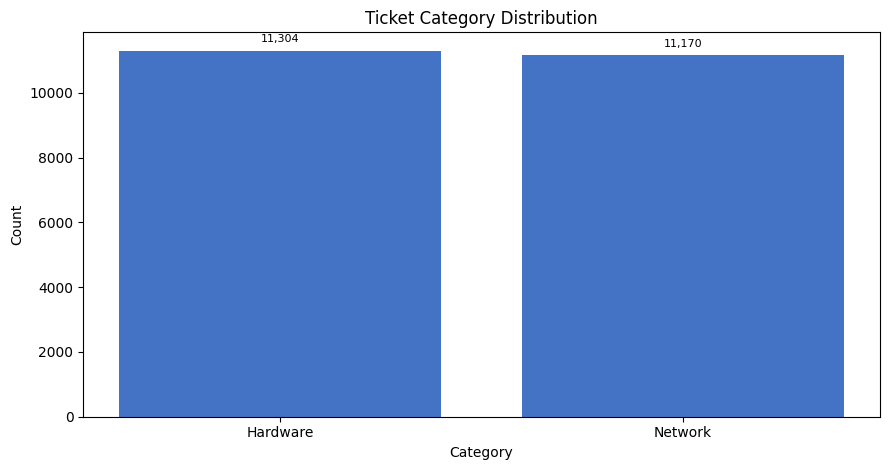

  ✅  Plot saved → /content/drive/MyDrive/Innodatatics_Capstone/ticket_eda_plots/02_ticket_priority.png


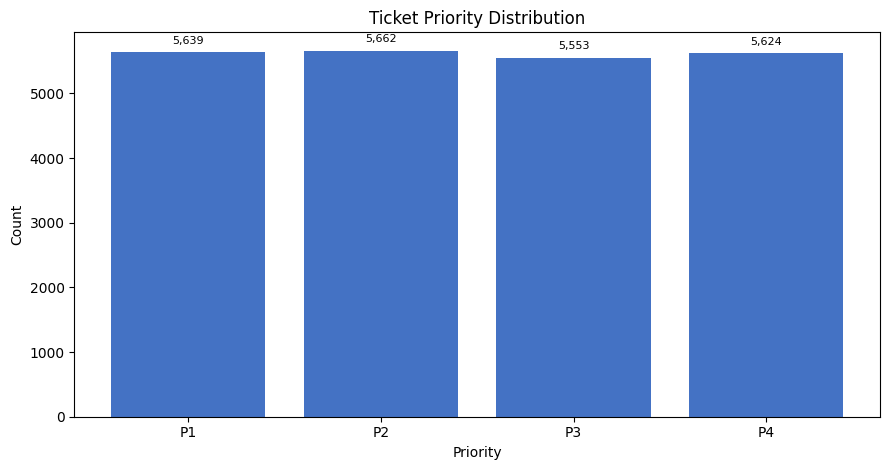

  ✅  Plot saved → /content/drive/MyDrive/Innodatatics_Capstone/ticket_eda_plots/03_issue_type.png


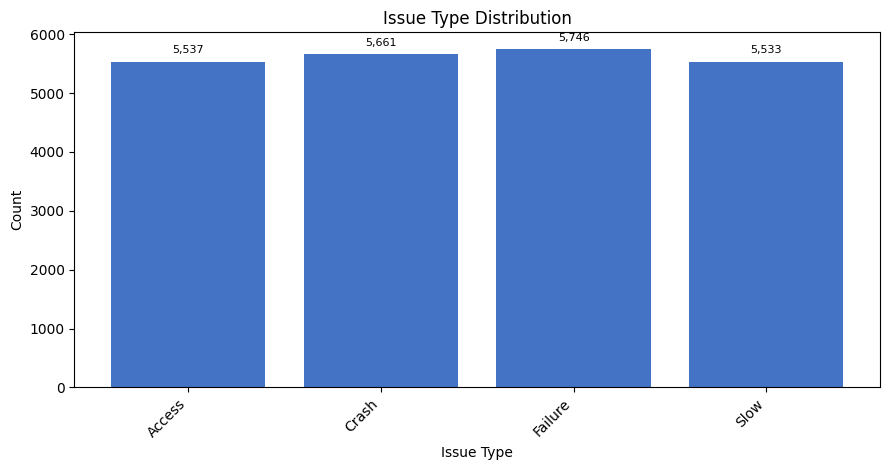

  ✅  Plot saved → /content/drive/MyDrive/Innodatatics_Capstone/ticket_eda_plots/04_sla_breach.png


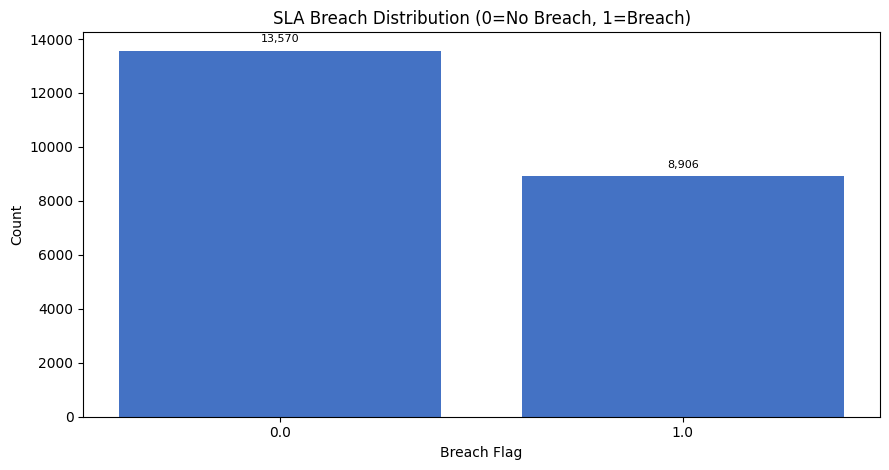

Overall SLA breach rate: 39.6%
Note: ~40% breach rate is near-uniform in synthetic data.
Real operational data will show stronger differentiation by priority and tier.


In [11]:
# =========================
# 4A. Target class distributions
# =========================
# Understanding class balance is the first step before any modeling.
# Near-equal class splits (like ~60/40) don't need SMOTE.
# Heavily imbalanced classes (<10% minority) need class weighting or oversampling.

labeled_bar(base["ticket_category"].value_counts().sort_index(),
            "Ticket Category Distribution", "Category", "Count",
            save="01_ticket_category.png")

labeled_bar(base["ticket_priority"].value_counts().sort_index(),
            "Ticket Priority Distribution", "Priority", "Count",
            save="02_ticket_priority.png")

labeled_bar(base["issue_type"].value_counts().sort_index(),
            "Issue Type Distribution", "Issue Type", "Count",
            rotate=45, save="03_issue_type.png")

base["sla_num"] = pd.to_numeric(base["sla_breach_flag"], errors="coerce")
labeled_bar(base["sla_num"].value_counts().sort_index(),
            "SLA Breach Distribution (0=No Breach, 1=Breach)", "Breach Flag", "Count",
            save="04_sla_breach.png")

print(f"Overall SLA breach rate: {base['sla_num'].mean():.1%}")
print("Note: ~40% breach rate is near-uniform in synthetic data.")
print("Real operational data will show stronger differentiation by priority and tier.")


  ✅  Plot saved → /content/drive/MyDrive/Innodatatics_Capstone/ticket_eda_plots/05_monthly_volume.png


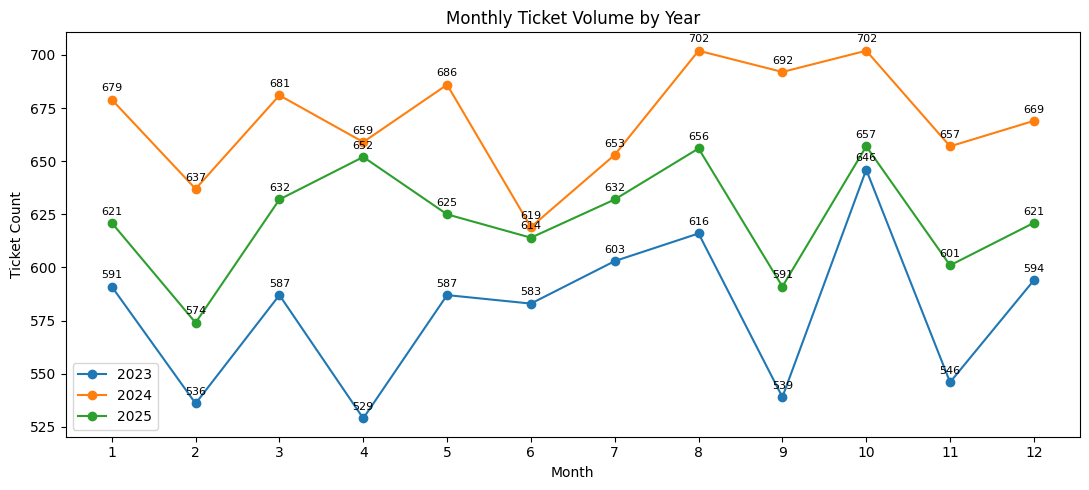

  ✅  Plot saved → /content/drive/MyDrive/Innodatatics_Capstone/ticket_eda_plots/06_volume_by_hour.png


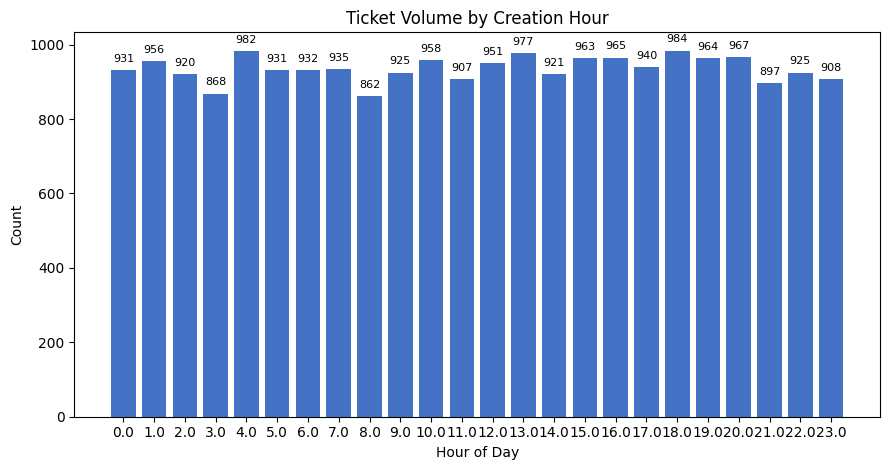

  ✅  Plot saved → /content/drive/MyDrive/Innodatatics_Capstone/ticket_eda_plots/07_volume_by_dow.png


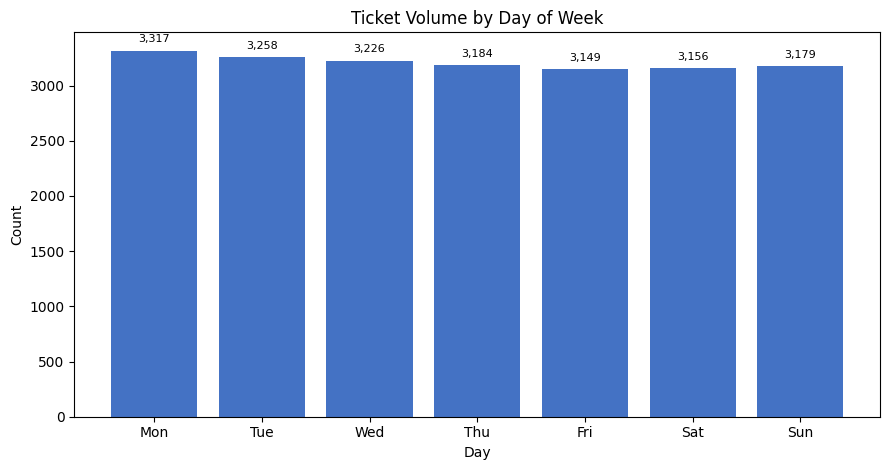

In [12]:
# =========================
# 4B. Temporal trends
# =========================
# Time patterns inform the is_weekend, is_business_hours, created_hour
# and created_dayofweek features created in NB2.

ts = base.dropna(subset=["ticket_created_timestamp"]).copy()
ts["source_year"] = ts["ticket_created_timestamp"].dt.year

# ── Monthly volume by year ─────────────────────────────────────────────────
monthly = (
    ts.groupby(["source_year", "ticket_month"])
    .size()
    .reset_index(name="count")
    .sort_values(["source_year", "ticket_month"])
)
fig, ax = plt.subplots(figsize=(11, 5))
for year in sorted(monthly["source_year"].dropna().unique()):
    sub = monthly[monthly["source_year"] == year]
    ax.plot(sub["ticket_month"], sub["count"], marker="o", label=str(int(year)))
    add_data_labels(ax, sub["ticket_month"], sub["count"])
ax.set_title("Monthly Ticket Volume by Year")
ax.set_xlabel("Month")
ax.set_ylabel("Ticket Count")
ax.set_xticks(range(1, 13))
ax.legend()
save_plot("05_monthly_volume.png")

# ── Volume by hour of day ─────────────────────────────────────────────────
labeled_bar(ts.groupby("ticket_hour").size().sort_index(),
            "Ticket Volume by Creation Hour", "Hour of Day", "Count",
            save="06_volume_by_hour.png")

# ── Volume by day of week ─────────────────────────────────────────────────
dow_map = {0:"Mon",1:"Tue",2:"Wed",3:"Thu",4:"Fri",5:"Sat",6:"Sun"}
labeled_bar(ts.groupby("ticket_dayofweek").size().rename(index=dow_map),
            "Ticket Volume by Day of Week", "Day", "Count",
            save="07_volume_by_dow.png")


  ✅  Plot saved → /content/drive/MyDrive/Innodatatics_Capstone/ticket_eda_plots/08_breach_by_priority.png


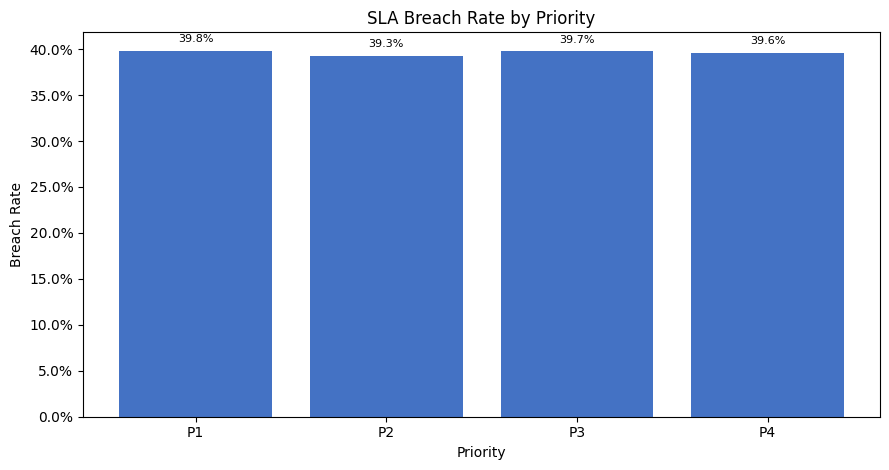

  ✅  Plot saved → /content/drive/MyDrive/Innodatatics_Capstone/ticket_eda_plots/09_breach_by_tier.png


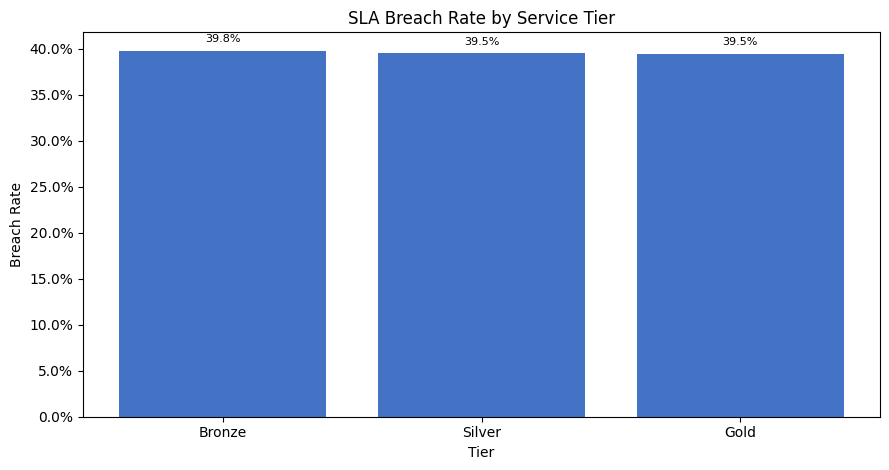

  ✅  Plot saved → /content/drive/MyDrive/Innodatatics_Capstone/ticket_eda_plots/10_breach_by_issue.png


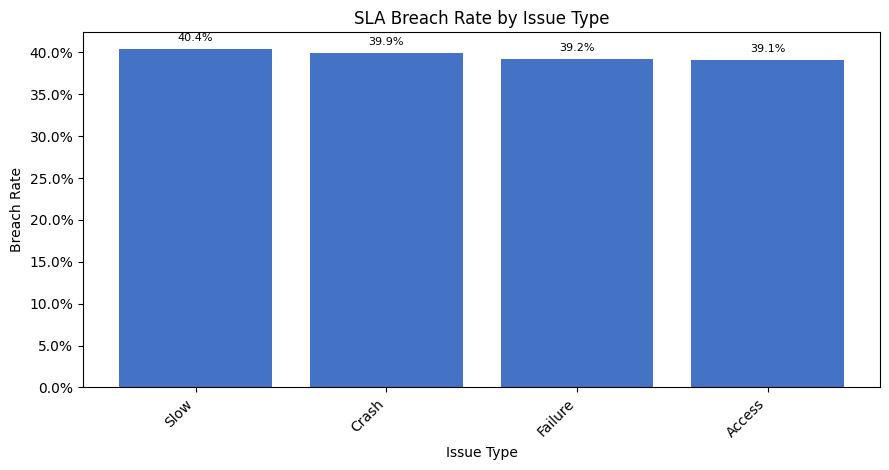

  ✅  Plot saved → /content/drive/MyDrive/Innodatatics_Capstone/ticket_eda_plots/11_breach_by_channel.png


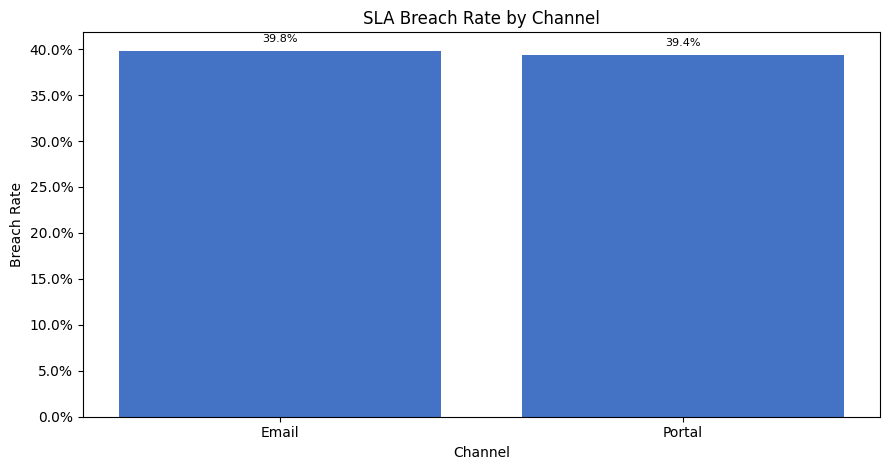

  ✅  Plot saved → /content/drive/MyDrive/Innodatatics_Capstone/ticket_eda_plots/12_monthly_breach_trend.png


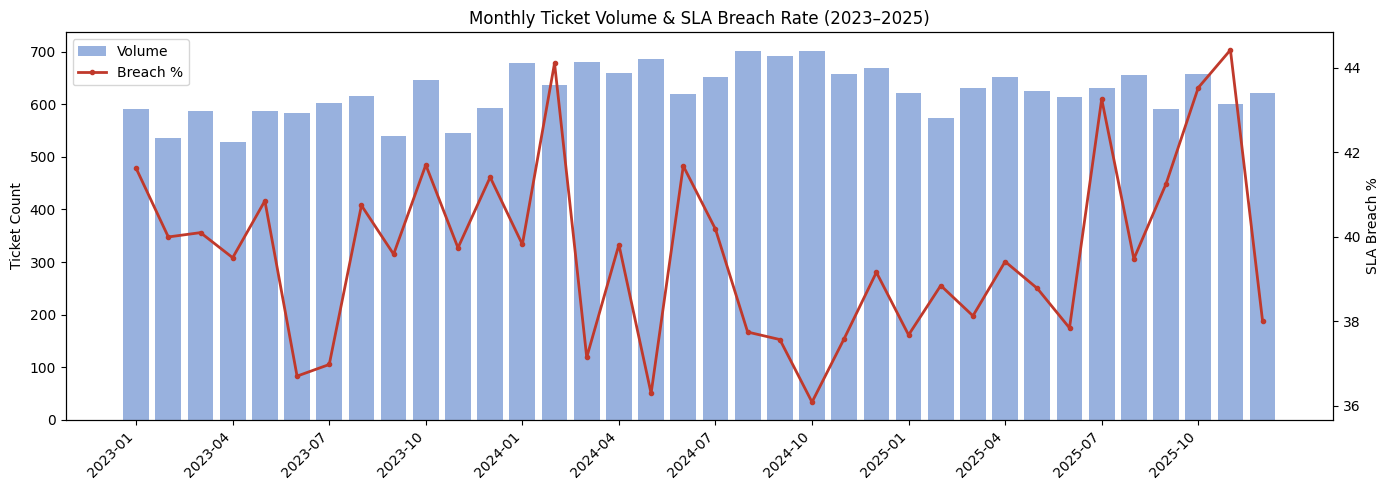

In [13]:
# =========================
# 4C. SLA breach analysis
# =========================
# SLA breach rate by every categorical dimension.
# These patterns inform M2 (SLA Breach Prediction) feature importance.
# Also produces the monthly compliance trend chart for the dashboard.

labeled_bar(base.groupby("ticket_priority")["sla_num"].mean().sort_index(),
            "SLA Breach Rate by Priority", "Priority", "Breach Rate",
            percent=True, save="08_breach_by_priority.png")

if "service_tier" in base.columns:
    labeled_bar(base.groupby("service_tier")["sla_num"].mean().sort_values(ascending=False),
                "SLA Breach Rate by Service Tier", "Tier", "Breach Rate",
                percent=True, save="09_breach_by_tier.png")

labeled_bar(base.groupby("issue_type")["sla_num"].mean().sort_values(ascending=False),
            "SLA Breach Rate by Issue Type", "Issue Type", "Breach Rate",
            rotate=45, percent=True, save="10_breach_by_issue.png")

if "ticket_channel" in base.columns:
    labeled_bar(base.groupby("ticket_channel")["sla_num"].mean().sort_values(ascending=False),
                "SLA Breach Rate by Channel", "Channel", "Breach Rate",
                percent=True, save="11_breach_by_channel.png")

# ── Monthly breach trend (dual-axis volume + rate) ────────────────────────
ts2 = base.dropna(subset=["ticket_created_timestamp"]).copy()
ts2["ym"] = ts2["ticket_created_timestamp"].dt.to_period("M")
mb = ts2.groupby("ym").agg(tickets=("year_ticket_id","count"),
                             breach_rate=("sla_num","mean")).reset_index()
mb["ym"] = mb["ym"].astype(str)
fig, ax1 = plt.subplots(figsize=(14,5))
ax2 = ax1.twinx()
ax1.bar(range(len(mb)), mb["tickets"], alpha=0.55, color="#4472C4", label="Volume")
ax2.plot(range(len(mb)), mb["breach_rate"]*100, color="#C0392B",
         linewidth=2, marker="o", markersize=3, label="Breach %")
ax1.set_xticks(range(0,len(mb),3))
ax1.set_xticklabels(mb["ym"].iloc[::3], rotation=45, ha="right")
ax1.set_ylabel("Ticket Count"); ax2.set_ylabel("SLA Breach %")
ax1.set_title("Monthly Ticket Volume & SLA Breach Rate (2023–2025)")
lines = ax1.get_legend_handles_labels()[0]+ax2.get_legend_handles_labels()[0]
labels = ax1.get_legend_handles_labels()[1]+ax2.get_legend_handles_labels()[1]
ax1.legend(lines, labels, loc="upper left")
save_plot("12_monthly_breach_trend.png")


  ✅  Plot saved → /content/drive/MyDrive/Innodatatics_Capstone/ticket_eda_plots/13_res_time_priority.png


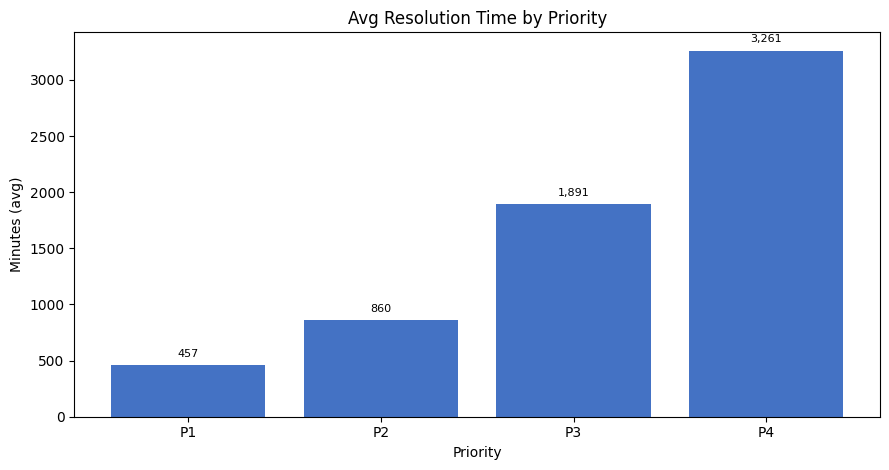

  ✅  Plot saved → /content/drive/MyDrive/Innodatatics_Capstone/ticket_eda_plots/14_res_time_issue.png


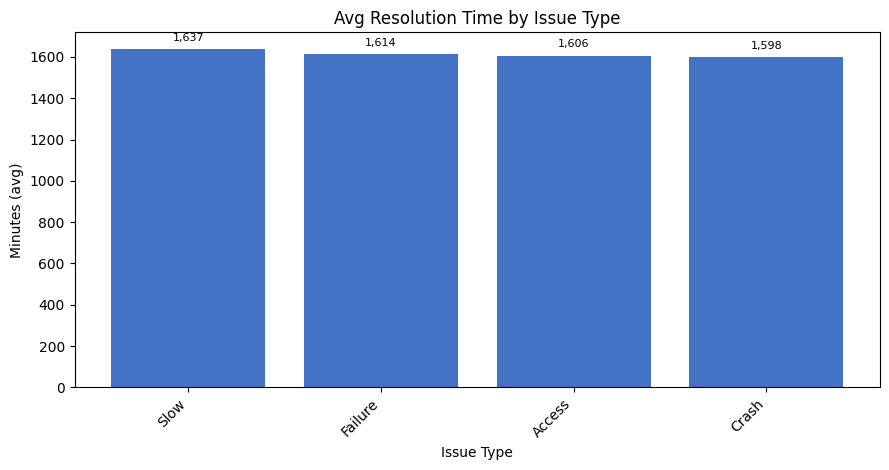

  ✅  Plot saved → /content/drive/MyDrive/Innodatatics_Capstone/ticket_eda_plots/15_res_time_category.png


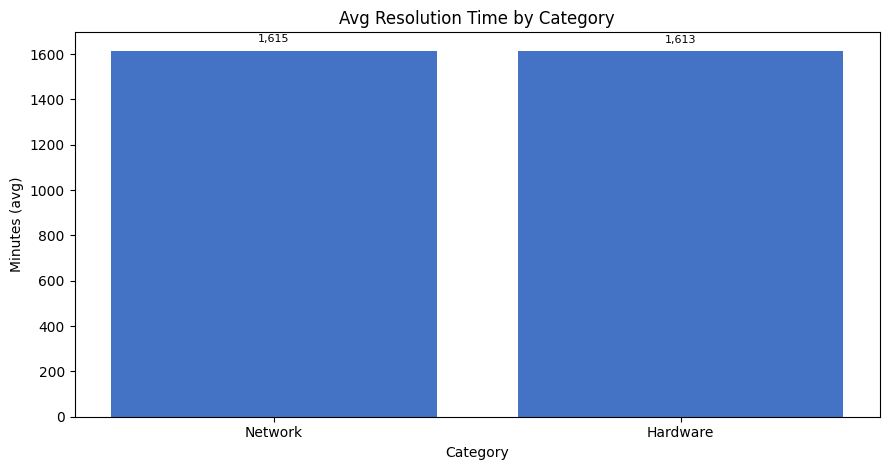


Resolution time statistics:
count    22474.0
mean      1613.9
std       1241.5
min        168.0
25%        546.0
50%       1273.8
75%       2563.8
max       5179.4


In [14]:
# =========================
# 4D. Resolution time analysis
# =========================
# Resolution time distributions show where service delivery bottlenecks occur.
# Engineers and device types with consistently high resolution times are
# flagged in the dashboard and deprioritised in NB3 assignment scoring.

labeled_bar(base.groupby("ticket_priority")["resolution_time_minutes"].mean().sort_index(),
            "Avg Resolution Time by Priority", "Priority", "Minutes (avg)",
            save="13_res_time_priority.png")
labeled_bar(base.groupby("issue_type")["resolution_time_minutes"].mean().sort_values(ascending=False),
            "Avg Resolution Time by Issue Type", "Issue Type", "Minutes (avg)",
            rotate=45, save="14_res_time_issue.png")
labeled_bar(base.groupby("ticket_category")["resolution_time_minutes"].mean().sort_values(ascending=False),
            "Avg Resolution Time by Category", "Category", "Minutes (avg)",
            save="15_res_time_category.png")
print("\nResolution time statistics:")
print(base["resolution_time_minutes"].describe().round(1).to_string())


Engineer performance profile (top 10 by tickets handled):


,engineer_id,engineer_name,specialization,tickets_handled,avg_resolution_time,sla_success_rate,reopen_rate
0,E003,Eng_3,Network,1196,1637.132201,0.6196,0.501672
1,E020,Eng_20,Network,1196,1616.795494,0.6162,0.500000
2,E013,Eng_13,Server,1171,1566.499761,0.6097,0.508113
3,E010,Eng_10,Network,1160,1664.726273,0.5922,0.512069
4,E015,Eng_15,Network,1155,1582.016456,0.5697,0.500433
5,E007,Eng_7,Network,1146,1676.394606,0.6230,0.474695
6,E009,Eng_9,Network,1138,1537.230255,0.6125,0.516696
7,E019,Eng_19,Server,1137,1655.521539,0.6060,0.477573
8,E008,Eng_8,Server,1133,1648.711703,0.6240,0.480141
9,E005,Eng_5,Network,1133,1648.255751,0.6064,0.507502


  ✅  Plot saved → /content/drive/MyDrive/Innodatatics_Capstone/ticket_eda_plots/16_engineer_sla.png


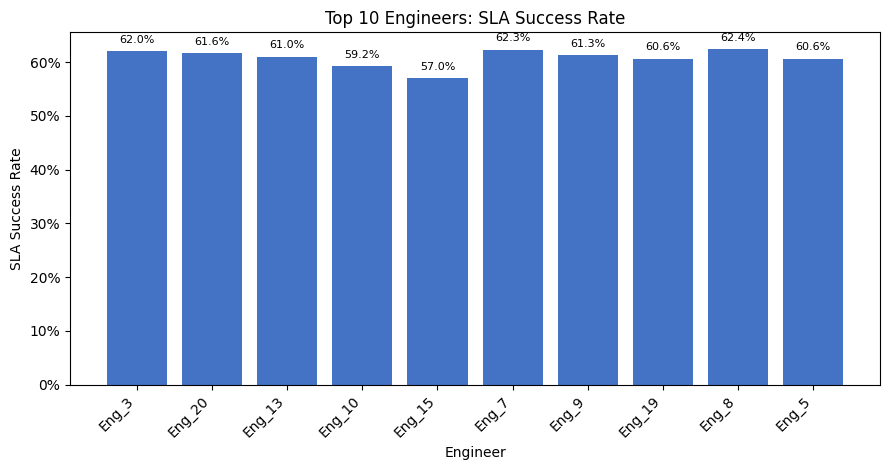

In [15]:
# =========================
# 4E. Engineer performance profiling
# =========================
# This table is saved to engineer_perf.pkl and loaded directly by NB3.
# It provides the historical sla_success_rate and issue_counts used in
# the AHP-based engineer assignment scoring.

engineer_perf = (
    base.groupby(["engineer_id", "engineer_name", "specialization"], dropna=False)
    .agg(
        tickets_handled     = ("year_ticket_id", "count"),
        avg_resolution_time = ("resolution_time_minutes", "mean"),
        avg_first_response  = ("first_response_time_minutes", "mean"),
        sla_success_rate    = ("sla_num",
                               lambda s: round(1 - s.fillna(0).mean(), 4)),
        reopen_rate         = ("ticket_reopen_flag",
                               lambda s: pd.to_numeric(s, errors="coerce").fillna(0).mean()),
        category_counts     = ("ticket_category", lambda s: s.value_counts().to_dict()),
        issue_counts        = ("issue_type",       lambda s: s.value_counts().to_dict()),
    )
    .sort_values(["tickets_handled","sla_success_rate"], ascending=[False,False])
    .reset_index()
)

print("Engineer performance profile (top 10 by tickets handled):")
display(engineer_perf[[
    "engineer_id","engineer_name","specialization",
    "tickets_handled","avg_resolution_time","sla_success_rate","reopen_rate"
]].head(10))

top_sla = (engineer_perf.dropna(subset=["engineer_name"])
           .sort_values("tickets_handled", ascending=False)
           .head(10).set_index("engineer_name")["sla_success_rate"])
labeled_bar(top_sla,"Top 10 Engineers: SLA Success Rate",
            "Engineer","SLA Success Rate",rotate=45,percent=True,save="16_engineer_sla.png")


,metric,value
0,unique_nlp_text_detailed_values,15364.00
1,missing_detailed_pct,31.69
2,median_token_count_detailed,50.00
3,repeated_text_row_pct,31.69
4,unique_combined_text_values,15372.00


  ✅  Plot saved → /content/drive/MyDrive/Innodatatics_Capstone/ticket_eda_plots/17_token_distribution.png


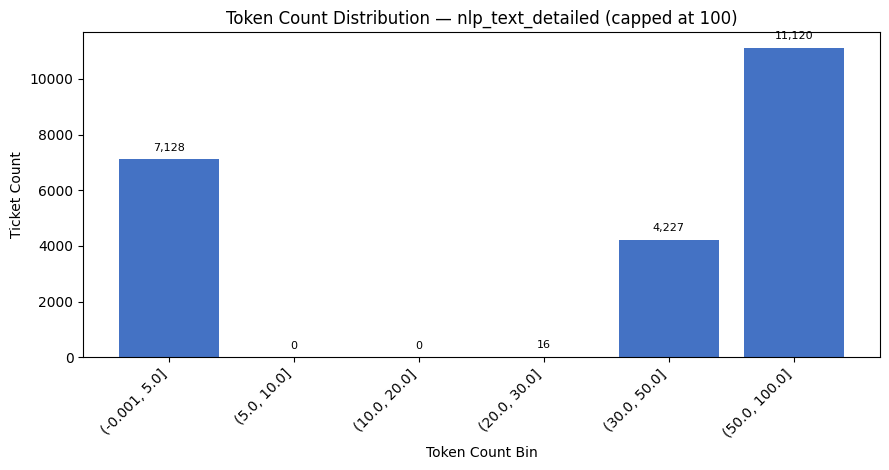

In [16]:
# =========================
# 4F. Text quality audit
# =========================
# ticket_detailed_description is the primary NLP field for the recommendation engine.
# This cell audits how many unique values exist and what the token count distribution
# looks like. Low uniqueness or very few tokens indicate text data quality issues.
#
# Known issue flagged to sponsor (14-Mar-2026):
# Initial delivery had very few unique values in ticket_description and resolution_notes.
# Corrected data received. This cell re-audits the latest delivery.

text_summary = pd.DataFrame({
    "metric": [
        "unique_nlp_text_detailed_values",
        "missing_detailed_pct",
        "median_token_count_detailed",
        "repeated_text_row_pct",
        "unique_combined_text_values",
    ],
    "value": [
        int(base["nlp_text_detailed"].nunique()),
        round(base["detailed_desc_missing"].mean() * 100, 2),
        float(base["token_count_detailed"].median()),
        round(base["is_repeated_text"].mean() * 100, 2),
        int(base["combined_text"].nunique()),
    ]
})
display(text_summary)

token_bins = pd.cut(
    base["token_count_detailed"].clip(upper=100),
    bins=[0, 5, 10, 20, 30, 50, 100],
    include_lowest=True
).value_counts().sort_index()
labeled_bar(token_bins, "Token Count Distribution — nlp_text_detailed (capped at 100)",
            "Token Count Bin", "Ticket Count", rotate=45, save="17_token_distribution.png")


# 5. Save Outputs

## Objective
Persist all outputs that Modules 2, 3 and 4 need. All files write directly to
Google Drive so the next notebook can load them without any file transfers.


In [17]:
# =========================
# 5A. Prepare reco_base for the recommendation engine
# =========================
# reco_base is the filtered subset of base used for TF-IDF training
# and similar-ticket retrieval in NB2 and NB3.
#
# Filter criteria:
#   - nlp_text_detailed must not be "unknown" (need real text for TF-IDF)
#   - resolution_notes must be present (needed for suggested resolution output)
#
# reco_text = nlp_text_detailed | issue_type | device_type
# ticket_description is NOT included in reco_text.

reco_base = base.copy()
reco_base["ticket_reopen_flag_num"] = (
    pd.to_numeric(reco_base["ticket_reopen_flag"], errors="coerce").fillna(0)
)
reco_base = reco_base[
    reco_base["nlp_text_detailed"].notna() &
    reco_base["nlp_text_detailed"].ne("unknown") &
    reco_base["resolution_notes"].notna()
].copy()

reco_base["reco_text"] = (
    reco_base["nlp_text_detailed"].fillna("unknown").astype(str) + " | " +
    reco_base["issue_type"].fillna("unknown").astype(str)         + " | " +
    reco_base["device_type"].fillna("unknown").astype(str)
)

print(f"reco_base: {len(reco_base):,} rows")
print("TF-IDF trains on nlp_text_detailed (ticket_detailed_description) only.")

# =========================
# 5B. Driver tables for NB4 dashboard
# =========================
resolution_driver_tables = {
    "by_priority":   base.groupby("ticket_priority")["resolution_time_minutes"].mean().sort_values(ascending=False),
    "by_category":   base.groupby("ticket_category")["resolution_time_minutes"].mean().sort_values(ascending=False),
    "by_issue_type": base.groupby("issue_type")["resolution_time_minutes"].mean().sort_values(ascending=False),
    "by_channel":    base.groupby("ticket_channel")["resolution_time_minutes"].mean().sort_values(ascending=False),
}
volume_driver_tables = {
    "by_priority":   base["ticket_priority"].value_counts(),
    "by_category":   base["ticket_category"].value_counts(),
    "by_issue_type": base["issue_type"].value_counts(),
}

# =========================
# 5C. Save all outputs to Drive
# =========================
save_pkl(base,                     "ticket_base.pkl")
save_pkl(reco_base,                "reco_base.pkl")
save_pkl(engineer_perf,            "engineer_perf.pkl")
save_pkl(schema_diffs,             "schema_diffs.pkl")
save_pkl(resolution_driver_tables, "resolution_driver_tables.pkl")
save_pkl(volume_driver_tables,     "volume_driver_tables.pkl")

print("\n✅  Module 1 — EDA complete.")
print(f"   All outputs saved to: {PKL_DIR}")
print("   Next → open Ticket_02_Models_Recommendations.ipynb")


reco_base: 15,363 rows
TF-IDF trains on nlp_text_detailed (ticket_detailed_description) only.
  ✅  Saved → /content/drive/MyDrive/Innodatatics_Capstone/ticket_pkl_outputs/ticket_base.pkl
  ✅  Saved → /content/drive/MyDrive/Innodatatics_Capstone/ticket_pkl_outputs/reco_base.pkl
  ✅  Saved → /content/drive/MyDrive/Innodatatics_Capstone/ticket_pkl_outputs/engineer_perf.pkl
  ✅  Saved → /content/drive/MyDrive/Innodatatics_Capstone/ticket_pkl_outputs/schema_diffs.pkl
  ✅  Saved → /content/drive/MyDrive/Innodatatics_Capstone/ticket_pkl_outputs/resolution_driver_tables.pkl
  ✅  Saved → /content/drive/MyDrive/Innodatatics_Capstone/ticket_pkl_outputs/volume_driver_tables.pkl

✅  Module 1 — EDA complete.
   All outputs saved to: /content/drive/MyDrive/Innodatatics_Capstone/ticket_pkl_outputs
   Next → open Ticket_02_Models_Recommendations.ipynb
